# DUET Classification Notebook

Этот блокнот приведён в соответствие с текущей архитектурой DUET для **классификации временных рядов**:
- **TCM** сегментирует ряд на патчи, выделяет тренд/сезонность и маршрутизирует их по temporal-кластерам.
- **CCM** работает в частотной области, учит межканальные связи и разреживает маску.
- **Fusion** объединяет temporal-признаки и маску каналов, после чего **classification head** выдаёт logits классов.

Ниже используются параметры `K_t`, `K_c`, `d_c`, `top_k`, а также RevIN/InstanceNorm в соответствии с `architecture.md`.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# @title Импорты
import sys
sys.path.append("/content/drive/MyDrive/stocks/duet/duet_class")

from pipeline.config import DUETConfig
from pipeline import preprocess, train, evaluate, predict
from pipeline.prepare_and_check import FinancialTimeSeriesPreparer
from pipeline.wf_slicer import GlobalNormConfig, SplitConfig, WalkForwardWindowSlicerVec, WindowConfig
from duet.model import DUETModel
from torch.utils.data import DataLoader, TensorDataset
import torch
import joblib
import random

import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight


In [3]:
# Настройки
DATA_PATH = "/content/drive/MyDrive/stocks/Data/anomaly/anomaly_df_binance_BTCUSDT_futures_cufOff_1.5.joblib"
LABELS_PATH = "/content/drive/MyDrive/stocks/Data/anomaly/Dataset_2_7class_clear - Dataset_2_7class_clear.csv.csv"
device = "cuda" if torch.cuda.is_available() else "cpu"

config = DUETConfig(
    # =========================
    # Общие параметры
    # =========================
    split_ratio = (0.70, 0.15, 0.15),
    timestamp_col = "timestamp",
    features = [
       'Open', 'High', 'Low', 'Close',
      #  'Volume',
    ],                           # Название колонок для обучения
    forecast = 'target',          # Название колонки с таргетом
    # нормализация не нужна (дуэт все делает сам внутри себя)
    #============================
    not_to_normalise = [],       # Название колонок, которые НЕ НАДО нормализовать
    scaler = 'NONE',             # Тип нормализации (STD, MINMAX, QUANT)
    #============================
    y_end_offset = 0,             # Смещение таргета: Детекция t0=0 или предикт t+1..N=+1...+N
    x_end_offset=+20,              # Смещение инпута в будущее: t0=0, t+1...N = +1...+N
    seq_len = 110,                # Длина входной последовательности
    num_classes = 7,             # кол-во классов
    patch_len = 60,               # Длина патча (TCM)
    stride = 20,                  # Шаг между патчами (TCM)
    moving_avg = 25,              # Размер окна скользящего сглаживания

    K_t = 3,                    # Кол-во временных кластеров (TCM)
    K_c = 9,                    # Кол-во кластеров каналов (CCM)
    d_c = 128,                   # Размерность embedding каналов (CCM)
    top_k = 5,                  # Кол-во связей при разреживании маски
    use_revin = True,           # Включить RevIN/InstanceNorm (если отключить, то нужно нормализовать данные отдельно)
    revin_affine = True,        # Использовать affine параметры в RevIN
    revin_eps = 1e-5,           # Эпсилон для стабильности RevIN

    # =========================
    # Параметры модели
    # =========================
    d_model = 256,               # Размерность скрытого пространства в attention
    d_ff = 1024,                 # Размерность feedforward слоя
    n_heads = 4,                # Количество голов в multi-head attention
    e_layers = 2,               # Количество слоев в encoder (CCM)
    dropout = 0.1,            # Dropout во всех слоях attention
    fc_dropout = 0.1,         # Dropout в выходном head слое
    activation = "relu",        # Активационная функция (relu, gelu, elu)
    num_experts = 8,            # Число экспертов (в Router, если используется)
    report_freq = 10,            # Частота появления confusion matrix

    # =========================
    # Режимы обработки
    # =========================
    CI = True,                 # Channel-Independent режим (если False — shared weights)
    use_router = True,          # Включить распределительный роутер
    timeenc = 1,                # Использовать time encoding (0 = без, 1 = sin/cos и т.п.)

    # =========================
    # Настройки обучения
    # =========================
    batch_size=32,          # можно немного увеличить при хорошем GPU
    epochs=100,             # больше эпох для более тонкой настройки
    learning_rate=1e-4,     # стандартный LR для Adam
    weight_decay=1e-5,
    patience=100,            # early stopping не слишком строгий

    # =========================
    # Прочее
    # =========================
    checkpoint_best = '/content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_005.pt',       # Путь для сохранения лучших по val_accuracy весов
    checkpoint_final = '/content/drive/MyDrive/stocks/duet/duet_class/weights/final_weights_005.pt',      # Путь для сохранения финальных весов
    seed = 33,                  # Фиксированное зерно генератора случайных чисел
    verbose = True,            # Печать хода обучения
)

"""
Устанавливает seed для numpy, random, torch (вкл. CUDA).
Гарантирует воспроизводимость.
"""

random.seed(config.seed)
np.random.seed(config.seed)
torch.manual_seed(config.seed)
torch.cuda.manual_seed_all(config.seed)

In [4]:
# @title Загрузка данных

df = joblib.load(DATA_PATH)
labels = pd.read_csv(LABELS_PATH)

data_preparer = FinancialTimeSeriesPreparer(
    tz="UTC",
    timestamp_col="timestamp",
    drop_warmup=True,
)
labels_preparer = FinancialTimeSeriesPreparer(
    tz="UTC",
    timestamp_col="Time_close",
    drop_warmup=True,
)

df, _ = data_preparer.prepare(df, ensure_ohlcv=True, from_date="2023-01-01", to_date="2024-01-30")
labels, _ = labels_preparer.prepare(labels, ensure_ohlcv=False, from_date="2023-01-01", to_date="2024-01-30")

labels.index = labels.index.round("1min")   # до ближайшей минуты
print(f"Labels index from {labels.index[0]} to {labels.index[-1]}")

df['target'] = labels['target']
df.fillna({'target':-1}, inplace=True)
# df.loc[df['zScore_bin'] == 0, 'target'] = -1 # все что не аномалия помечаем как класс -1
df['target'].value_counts()

Labels index from 2023-01-01 18:12:00+00:00 to 2024-01-18 15:19:00+00:00


,count
target,
-1.0,565351
1.0,825
3.0,629
0.0,173
2.0,166
4.0,136
5.0,50
6.0,30


In [ ]:
# @title Слияние классов в класс антагонист (если надо)

# df.loc[df['target'] == 2, 'target'] = 9
# df.loc[df['target'] == 5, 'target'] = 9
# df.loc[df['target'] == 6, 'target'] = 9
# df.loc[df['target'] == 7, 'target'] = 9
# df.loc[df['target'] == 8, 'target'] = 9
# df['target'].value_counts()

In [5]:
# @title Добавляем временное кодирование (обязательно для ДУЭТ)
from pipeline.timefeatures import time_features_from_index

time_features = time_features_from_index(df.index, timeenc=config.timeenc)
time_feature_names = [f"timeenc_{i}" for i in range(time_features.shape[1])]
df[time_feature_names] = time_features
config.features = config.features + time_feature_names

print(f"Config features: {config.features}")

df.head()

Config features: ['Open', 'High', 'Low', 'Close', 'timeenc_0', 'timeenc_1', 'timeenc_2', 'timeenc_3', 'timeenc_4', 'timeenc_5', 'timeenc_6', 'timeenc_7', 'timeenc_8', 'timeenc_9']


,timestamp,Open,High,Low,Close,Volume,Quote_asset_volume,Number_of_trades,Taker_buy_base_asset_volume,Taker_buy_quote_asset_volume,...,timeenc_0,timeenc_1,timeenc_2,timeenc_3,timeenc_4,timeenc_5,timeenc_6,timeenc_7,timeenc_8,timeenc_9
datetime,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00+00:00,1672531200000,16537.5,16538.0,16534.3,16538.0,170.576,2.820697e+06,946,103.782,1.716165e+06,...,0.5,0.866025,0.201299,0.97953,-0.781832,0.62349,0.0,1.0,0.000000,1.000000
2023-01-01 00:01:00+00:00,1672531260000,16538.0,16538.0,16534.9,16534.9,44.287,7.323633e+05,570,19.098,3.158178e+05,...,0.5,0.866025,0.201299,0.97953,-0.781832,0.62349,0.0,1.0,0.104528,0.994522
2023-01-01 00:02:00+00:00,1672531320000,16534.9,16535.0,16531.3,16531.4,100.228,1.657072e+06,456,21.026,3.476265e+05,...,0.5,0.866025,0.201299,0.97953,-0.781832,0.62349,0.0,1.0,0.207912,0.978148
2023-01-01 00:03:00+00:00,1672531380000,16531.4,16531.4,16526.6,16526.9,317.879,5.254048e+06,980,79.937,1.321185e+06,...,0.5,0.866025,0.201299,0.97953,-0.781832,0.62349,0.0,1.0,0.309017,0.951057
2023-01-01 00:04:00+00:00,1672531440000,16527.0,16529.3,16523.0,16529.2,211.281,3.491635e+06,1113,79.049,1.306280e+06,...,0.5,0.866025,0.201299,0.97953,-0.781832,0.62349,0.0,1.0,0.406737,0.913545


In [6]:
# @title Доп. индикаторы
import pandas as pd
import numpy as np
from typing import Tuple

def calculate_rsi(df: pd.DataFrame, column: str, window: int = 14) -> pd.Series:
    # Вычисляем разницу между текущим и предыдущим значением цены
    delta = df[column].diff()

    # Выбираем положительные и отрицательные изменения
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    # Скользящее среднее приростов и падений
    avg_gain = gain.rolling(window=window, min_periods=window).mean()
    avg_loss = loss.rolling(window=window, min_periods=window).mean()

    # Вычисляем RS и RSI
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi

def calculate_bollinger_bands(df: pd.DataFrame, column: str, window: int = 20, num_std: int = 2) -> Tuple[pd.Series]:
    # Среднее значение за окно (SMA)
    middle_band = df[column].rolling(window=window).mean()

    # Стандартное отклонение за окно
    std_dev = df[column].rolling(window=window).std()

    # Расчет полос
    upper_band = middle_band + std_dev * num_std
    lower_band = middle_band - std_dev * num_std

    return upper_band, middle_band, lower_band


def compute_log_bolinger(df: pd.DataFrame, column: str, window: int, num_std:int = 2) -> pd.Series:
    rolling_std = df[column].rolling(window=window).std()
    rolling_mean = df[column].rolling(window=window).mean()
    upper_band = rolling_mean + num_std * rolling_std
    lower_band = rolling_mean - num_std * rolling_std
    bb_width = np.log(upper_band / lower_band)

    bb_width.fillna(0.00001, inplace=True)
    bb_width.replace(0, 0.00001, inplace=True)

    return bb_width

df['rsi_60'] = calculate_rsi(df, "Close", window = 60)
df['bb_up_60'], df['bb_mid_60'], df['bb_down_60'] = calculate_bollinger_bands(df, "Close", window = 60)
df['bb_width'] = compute_log_bolinger(df, "Close", window = 60)

new_faetures = ["rsi_60", "bb_up_60", "bb_mid_60", "bb_down_60", "bb_width"]

config.features = config.features + new_faetures
df, _ = data_preparer.prepare(df, ensure_ohlcv=False, from_date="2021-01-01", to_date="2025-12-30")

In [7]:
# @title Предобработка данных

split = SplitConfig(
    n_folds=1,
    mode="expanding",
    ratios=config.split_ratio,
    step_size=None,
    gap=0,
    sliding_train_size=None,
)

window = WindowConfig(
    x_window=config.seq_len,
    x_end_offset=config.x_end_offset,
    y_window=1,
    y_end_offset=config.y_end_offset,
    allow_left_context_for_x=False,
)

scaler_map = {"STD": "standard", "MINMAX": "minmax", "QUANT": "quantile", "NONE": "none"}
global_norm = GlobalNormConfig(scaler=scaler_map.get(config.scaler.upper(), "none"))

slicer = WalkForwardWindowSlicerVec(
    split=split,
    window=window,
    global_norm=global_norm,
    no_norm_cols=config.not_to_normalise,
    eps=1e-12,
    drop_incomplete_last_fold=True,
)

out = slicer.split_and_window(
    X=df[config.features],
    y=df[config.forecast],
    aux=df[['gaps', 'nan_filled', 'candle_error']]
)
fold0 = out["fold_0"]

x_train = fold0["train"]["X"]
y_train = fold0["train"]["y"][:, 0, 0].astype(int)
x_val = fold0["val"]["X"]
y_val = fold0["val"]["y"][:, 0, 0].astype(int)

x_test = fold0["test"]["X"]
y_test = fold0["test"]["y"][:, 0, 0].astype(int)

print(f"Train shape: {x_train.shape, y_train.shape}")
print(f"Val shape: {x_val.shape, y_val.shape}")
print(f"Test shape: {x_test.shape, y_test.shape}")


Train shape: ((397001, 110, 19), (397001,))
Val shape: ((84986, 110, 19), (84986,))
Test shape: ((84987, 110, 19), (84987,))


In [8]:
# @title Балансируем и убираем не аномалии
x_train, y_train = preprocess.balance_windows(x_train, y_train, max_ratio=100, exclude_labels=[-1])
x_val, y_val = preprocess.balance_windows(x_val, y_val, max_ratio=100, exclude_labels=[-1])
x_test, y_test = preprocess.balance_windows(x_test, y_test, max_ratio=100, exclude_labels=-1)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.fit_transform(y_val)

# Проверяем балансировку
unique, counts = np.unique(y_train, return_counts=True)
print("Классы после балансировки в трэйне:")
for k,v in zip(unique, counts):
  print(f"Class {k}: {v}")

unique, counts = np.unique(y_val, return_counts=True)
print("Классы после балансировки в трэйне:")
for k,v in zip(unique, counts):
  print(f"Class {k}: {v}")

# --- 3. Подсчет весов классов ---
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Распределение весов между класcами {class_weights}")



Балансировка: min=23, max=673, max_ratio=100.0 -> cap=2300
Балансировка: min=6, max=150, max_ratio=100.0 -> cap=600
Балансировка: min=2, max=14, max_ratio=100.0 -> cap=200
Классы после балансировки в трэйне:
Class 0: 130
Class 1: 673
Class 2: 148
Class 3: 487
Class 4: 123
Class 5: 43
Class 6: 23
Классы после балансировки в трэйне:
Class 0: 35
Class 1: 150
Class 2: 18
Class 3: 128
Class 4: 13
Class 5: 6
Распределение весов между класcами tensor([ 1.7879,  0.3454,  1.5705,  0.4773,  1.8897,  5.4053, 10.1056],
       device='cuda:0')


[1/100] Train Loss: 1.6011 | Train Acc: 0.4688 | Val Loss: 1.2763 | Val Acc: 0.7093 | Val Macro F1: 0.4591 | Val PR AUC: 0.5235
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_005.pt


[2/100] Train Loss: 1.3183 | Train Acc: 0.6083 | Val Loss: 1.1717 | Val Acc: 0.6549 | Val Macro F1: 0.4118 | Val PR AUC: 0.4950
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_005.pt


[3/100] Train Loss: 1.2093 | Train Acc: 0.6097 | Val Loss: 1.1111 | Val Acc: 0.6811 | Val Macro F1: 0.4359 | Val PR AUC: 0.5017
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_005.pt


[4/100] Train Loss: 1.1056 | Train Acc: 0.6425 | Val Loss: 1.0466 | Val Acc: 0.7093 | Val Macro F1: 0.4430 | Val PR AUC: 0.5039
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_005.pt


[5/100] Train Loss: 1.0496 | Train Acc: 0.6627 | Val Loss: 1.0332 | Val Acc: 0.6123 | Val Macro F1: 0.4113 | Val PR AUC: 0.5101
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_005.pt


[6/100] Train Loss: 0.9889 | Train Acc: 0.6699 | Val Loss: 1.0033 | Val Acc: 0.7348 | Val Macro F1: 0.4745 | Val PR AUC: 0.5338
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_005.pt


[7/100] Train Loss: 0.9333 | Train Acc: 0.6998 | Val Loss: 0.9316 | Val Acc: 0.7294 | Val Macro F1: 0.4970 | Val PR AUC: 0.5560
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_005.pt


[8/100] Train Loss: 0.8739 | Train Acc: 0.7215 | Val Loss: 0.9391 | Val Acc: 0.6634 | Val Macro F1: 0.4631 | Val PR AUC: 0.5661


[9/100] Train Loss: 0.8314 | Train Acc: 0.7148 | Val Loss: 0.8915 | Val Acc: 0.7150 | Val Macro F1: 0.4794 | Val PR AUC: 0.6053
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_005.pt


[10/100] Train Loss: 0.7837 | Train Acc: 0.7366 | Val Loss: 0.8959 | Val Acc: 0.7265 | Val Macro F1: 0.4795 | Val PR AUC: 0.5786


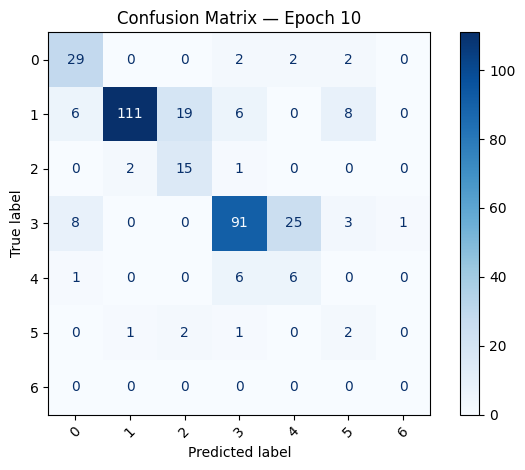

[11/100] Train Loss: 0.7506 | Train Acc: 0.7404 | Val Loss: 0.8996 | Val Acc: 0.6894 | Val Macro F1: 0.4736 | Val PR AUC: 0.5823


[12/100] Train Loss: 0.7342 | Train Acc: 0.7307 | Val Loss: 0.9492 | Val Acc: 0.6665 | Val Macro F1: 0.4209 | Val PR AUC: 0.5862


[13/100] Train Loss: 0.7139 | Train Acc: 0.7408 | Val Loss: 0.9176 | Val Acc: 0.6205 | Val Macro F1: 0.4528 | Val PR AUC: 0.5975


[14/100] Train Loss: 0.7076 | Train Acc: 0.7230 | Val Loss: 0.9206 | Val Acc: 0.6748 | Val Macro F1: 0.4733 | Val PR AUC: 0.5970


[15/100] Train Loss: 0.6713 | Train Acc: 0.7294 | Val Loss: 0.8948 | Val Acc: 0.7121 | Val Macro F1: 0.4766 | Val PR AUC: 0.6071


[16/100] Train Loss: 0.6609 | Train Acc: 0.7474 | Val Loss: 0.8828 | Val Acc: 0.7036 | Val Macro F1: 0.4826 | Val PR AUC: 0.5971
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_005.pt


[17/100] Train Loss: 0.5965 | Train Acc: 0.7532 | Val Loss: 0.8751 | Val Acc: 0.7348 | Val Macro F1: 0.5094 | Val PR AUC: 0.6110
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_005.pt


[18/100] Train Loss: 0.5891 | Train Acc: 0.7687 | Val Loss: 0.8430 | Val Acc: 0.7206 | Val Macro F1: 0.4898 | Val PR AUC: 0.6247
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_005.pt


[19/100] Train Loss: 0.5617 | Train Acc: 0.7673 | Val Loss: 0.8202 | Val Acc: 0.7576 | Val Macro F1: 0.5248 | Val PR AUC: 0.6319
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_005.pt


[20/100] Train Loss: 0.5353 | Train Acc: 0.7940 | Val Loss: 0.8251 | Val Acc: 0.7347 | Val Macro F1: 0.5078 | Val PR AUC: 0.6372


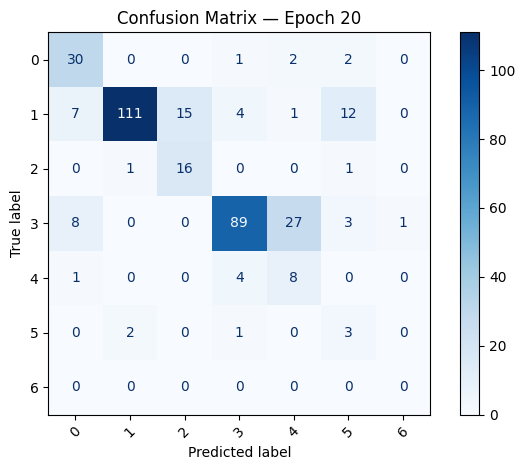

[21/100] Train Loss: 0.5366 | Train Acc: 0.7673 | Val Loss: 0.8772 | Val Acc: 0.7064 | Val Macro F1: 0.5001 | Val PR AUC: 0.6411


[22/100] Train Loss: 0.5129 | Train Acc: 0.7920 | Val Loss: 0.8479 | Val Acc: 0.7119 | Val Macro F1: 0.5102 | Val PR AUC: 0.6345


[23/100] Train Loss: 0.5016 | Train Acc: 0.7864 | Val Loss: 0.8524 | Val Acc: 0.7150 | Val Macro F1: 0.4954 | Val PR AUC: 0.6410


[24/100] Train Loss: 0.4875 | Train Acc: 0.7815 | Val Loss: 0.8167 | Val Acc: 0.7667 | Val Macro F1: 0.5126 | Val PR AUC: 0.6406
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_005.pt


[25/100] Train Loss: 0.4717 | Train Acc: 0.8015 | Val Loss: 0.8471 | Val Acc: 0.7436 | Val Macro F1: 0.5145 | Val PR AUC: 0.6352


[26/100] Train Loss: 0.4604 | Train Acc: 0.8016 | Val Loss: 0.8276 | Val Acc: 0.7176 | Val Macro F1: 0.4921 | Val PR AUC: 0.6367


[27/100] Train Loss: 0.4579 | Train Acc: 0.7893 | Val Loss: 0.8369 | Val Acc: 0.7407 | Val Macro F1: 0.5011 | Val PR AUC: 0.6425


[28/100] Train Loss: 0.4508 | Train Acc: 0.7934 | Val Loss: 0.8386 | Val Acc: 0.7324 | Val Macro F1: 0.4968 | Val PR AUC: 0.6427


[29/100] Train Loss: 0.4209 | Train Acc: 0.8155 | Val Loss: 0.8289 | Val Acc: 0.7466 | Val Macro F1: 0.5294 | Val PR AUC: 0.6509


[30/100] Train Loss: 0.4229 | Train Acc: 0.8173 | Val Loss: 0.8507 | Val Acc: 0.7178 | Val Macro F1: 0.5098 | Val PR AUC: 0.6424


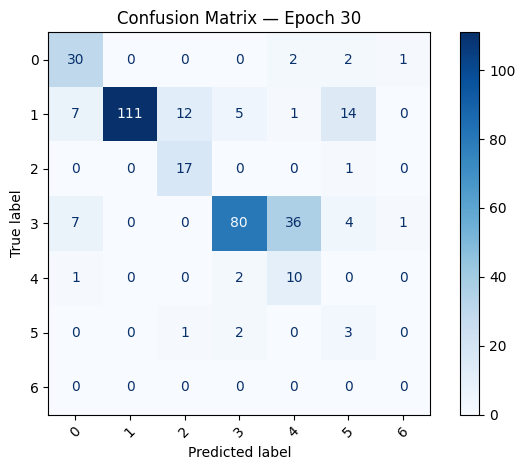

[31/100] Train Loss: 0.4073 | Train Acc: 0.8112 | Val Loss: 0.8505 | Val Acc: 0.7237 | Val Macro F1: 0.5237 | Val PR AUC: 0.6444


[32/100] Train Loss: 0.4076 | Train Acc: 0.8034 | Val Loss: 0.8131 | Val Acc: 0.7580 | Val Macro F1: 0.5238 | Val PR AUC: 0.6533
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_005.pt


[33/100] Train Loss: 0.3778 | Train Acc: 0.8256 | Val Loss: 0.8477 | Val Acc: 0.7152 | Val Macro F1: 0.5055 | Val PR AUC: 0.6429


[34/100] Train Loss: 0.3789 | Train Acc: 0.8226 | Val Loss: 0.8818 | Val Acc: 0.7182 | Val Macro F1: 0.5735 | Val PR AUC: 0.6446


[35/100] Train Loss: 0.3692 | Train Acc: 0.8225 | Val Loss: 0.8629 | Val Acc: 0.7239 | Val Macro F1: 0.6070 | Val PR AUC: 0.6511


[36/100] Train Loss: 0.3540 | Train Acc: 0.8299 | Val Loss: 0.8400 | Val Acc: 0.7409 | Val Macro F1: 0.5827 | Val PR AUC: 0.6495


[37/100] Train Loss: 0.3580 | Train Acc: 0.8319 | Val Loss: 0.8515 | Val Acc: 0.7892 | Val Macro F1: 0.5803 | Val PR AUC: 0.6442


[38/100] Train Loss: 0.3566 | Train Acc: 0.8309 | Val Loss: 0.9020 | Val Acc: 0.7038 | Val Macro F1: 0.5381 | Val PR AUC: 0.6478


[39/100] Train Loss: 0.3594 | Train Acc: 0.8282 | Val Loss: 0.8430 | Val Acc: 0.7494 | Val Macro F1: 0.5812 | Val PR AUC: 0.6514


[40/100] Train Loss: 0.3282 | Train Acc: 0.8442 | Val Loss: 0.8746 | Val Acc: 0.7466 | Val Macro F1: 0.5684 | Val PR AUC: 0.6469


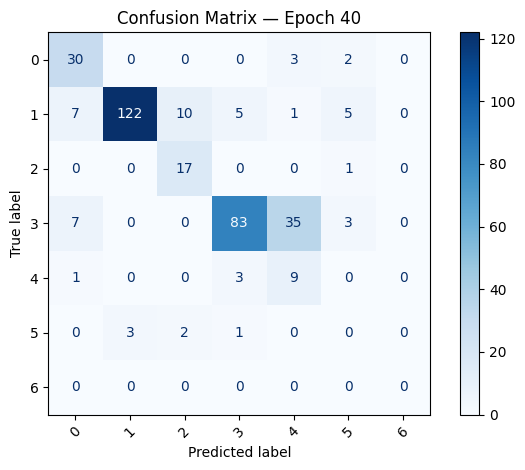

[41/100] Train Loss: 0.3322 | Train Acc: 0.8448 | Val Loss: 0.8522 | Val Acc: 0.7492 | Val Macro F1: 0.6032 | Val PR AUC: 0.6458


[42/100] Train Loss: 0.3285 | Train Acc: 0.8328 | Val Loss: 0.8458 | Val Acc: 0.7750 | Val Macro F1: 0.5191 | Val PR AUC: 0.6475


[43/100] Train Loss: 0.3228 | Train Acc: 0.8384 | Val Loss: 0.8770 | Val Acc: 0.7265 | Val Macro F1: 0.6018 | Val PR AUC: 0.6495


[44/100] Train Loss: 0.2923 | Train Acc: 0.8551 | Val Loss: 0.8601 | Val Acc: 0.7720 | Val Macro F1: 0.6277 | Val PR AUC: 0.6540


[45/100] Train Loss: 0.3215 | Train Acc: 0.8465 | Val Loss: 0.9089 | Val Acc: 0.7294 | Val Macro F1: 0.6093 | Val PR AUC: 0.6522


[46/100] Train Loss: 0.3006 | Train Acc: 0.8444 | Val Loss: 0.8838 | Val Acc: 0.7549 | Val Macro F1: 0.6199 | Val PR AUC: 0.6502


[47/100] Train Loss: 0.2915 | Train Acc: 0.8470 | Val Loss: 0.9030 | Val Acc: 0.7693 | Val Macro F1: 0.5751 | Val PR AUC: 0.6462


[48/100] Train Loss: 0.2825 | Train Acc: 0.8547 | Val Loss: 0.8515 | Val Acc: 0.7777 | Val Macro F1: 0.6235 | Val PR AUC: 0.6517


[49/100] Train Loss: 0.2817 | Train Acc: 0.8595 | Val Loss: 0.8796 | Val Acc: 0.7549 | Val Macro F1: 0.6178 | Val PR AUC: 0.6502


[50/100] Train Loss: 0.2586 | Train Acc: 0.8732 | Val Loss: 0.8753 | Val Acc: 0.7549 | Val Macro F1: 0.5281 | Val PR AUC: 0.6513


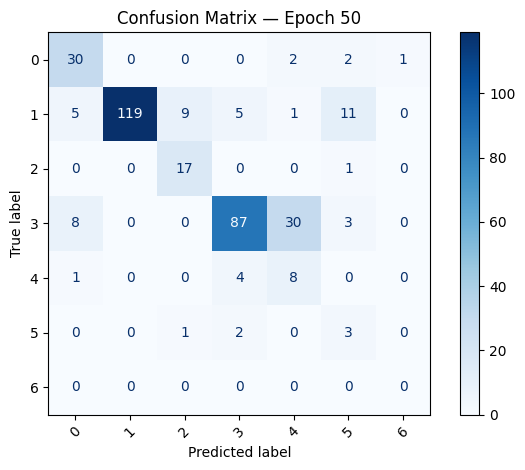

[51/100] Train Loss: 0.2614 | Train Acc: 0.8567 | Val Loss: 0.9188 | Val Acc: 0.7350 | Val Macro F1: 0.5594 | Val PR AUC: 0.6518


[52/100] Train Loss: 0.2609 | Train Acc: 0.8705 | Val Loss: 0.9721 | Val Acc: 0.7237 | Val Macro F1: 0.5629 | Val PR AUC: 0.6493


[53/100] Train Loss: 0.2454 | Train Acc: 0.8693 | Val Loss: 0.9384 | Val Acc: 0.7322 | Val Macro F1: 0.5178 | Val PR AUC: 0.6500


[54/100] Train Loss: 0.2426 | Train Acc: 0.8731 | Val Loss: 0.9449 | Val Acc: 0.7407 | Val Macro F1: 0.6111 | Val PR AUC: 0.6459


[55/100] Train Loss: 0.2459 | Train Acc: 0.8587 | Val Loss: 0.9127 | Val Acc: 0.7720 | Val Macro F1: 0.6151 | Val PR AUC: 0.6482


[56/100] Train Loss: 0.2378 | Train Acc: 0.8802 | Val Loss: 0.9039 | Val Acc: 0.7777 | Val Macro F1: 0.5424 | Val PR AUC: 0.6484


[57/100] Train Loss: 0.2317 | Train Acc: 0.8668 | Val Loss: 0.9521 | Val Acc: 0.7578 | Val Macro F1: 0.6116 | Val PR AUC: 0.6495


[58/100] Train Loss: 0.2288 | Train Acc: 0.8728 | Val Loss: 0.9434 | Val Acc: 0.7693 | Val Macro F1: 0.5018 | Val PR AUC: 0.6496


[59/100] Train Loss: 0.2333 | Train Acc: 0.8813 | Val Loss: 0.9744 | Val Acc: 0.7521 | Val Macro F1: 0.5843 | Val PR AUC: 0.6422


[60/100] Train Loss: 0.2184 | Train Acc: 0.8850 | Val Loss: 0.9467 | Val Acc: 0.7691 | Val Macro F1: 0.6075 | Val PR AUC: 0.6454


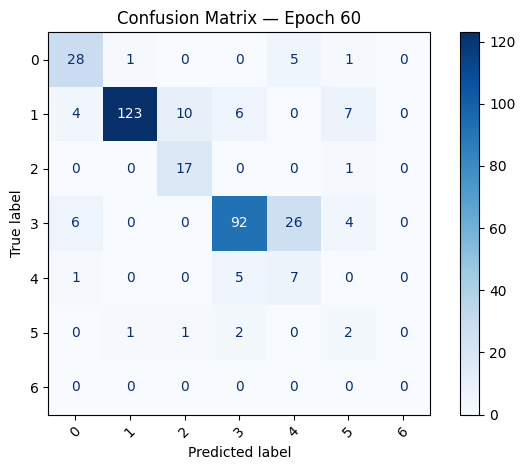

[61/100] Train Loss: 0.2278 | Train Acc: 0.8863 | Val Loss: 0.9729 | Val Acc: 0.7608 | Val Macro F1: 0.5072 | Val PR AUC: 0.6449


[62/100] Train Loss: 0.2144 | Train Acc: 0.8839 | Val Loss: 0.9373 | Val Acc: 0.7720 | Val Macro F1: 0.6250 | Val PR AUC: 0.6474


[63/100] Train Loss: 0.2155 | Train Acc: 0.8891 | Val Loss: 1.0115 | Val Acc: 0.7464 | Val Macro F1: 0.5843 | Val PR AUC: 0.6450


[64/100] Train Loss: 0.2220 | Train Acc: 0.8813 | Val Loss: 0.9924 | Val Acc: 0.7521 | Val Macro F1: 0.5928 | Val PR AUC: 0.6464


[65/100] Train Loss: 0.2027 | Train Acc: 0.8979 | Val Loss: 0.9587 | Val Acc: 0.7578 | Val Macro F1: 0.6252 | Val PR AUC: 0.6484


[66/100] Train Loss: 0.1951 | Train Acc: 0.8956 | Val Loss: 0.9837 | Val Acc: 0.7436 | Val Macro F1: 0.4878 | Val PR AUC: 0.6484


[67/100] Train Loss: 0.2025 | Train Acc: 0.8924 | Val Loss: 0.9255 | Val Acc: 0.7606 | Val Macro F1: 0.5296 | Val PR AUC: 0.6538


[68/100] Train Loss: 0.2022 | Train Acc: 0.8971 | Val Loss: 0.9547 | Val Acc: 0.7691 | Val Macro F1: 0.5108 | Val PR AUC: 0.6489


[69/100] Train Loss: 0.1897 | Train Acc: 0.9072 | Val Loss: 1.0060 | Val Acc: 0.7693 | Val Macro F1: 0.5799 | Val PR AUC: 0.6500


[70/100] Train Loss: 0.1902 | Train Acc: 0.9004 | Val Loss: 0.9840 | Val Acc: 0.7578 | Val Macro F1: 0.5997 | Val PR AUC: 0.6495


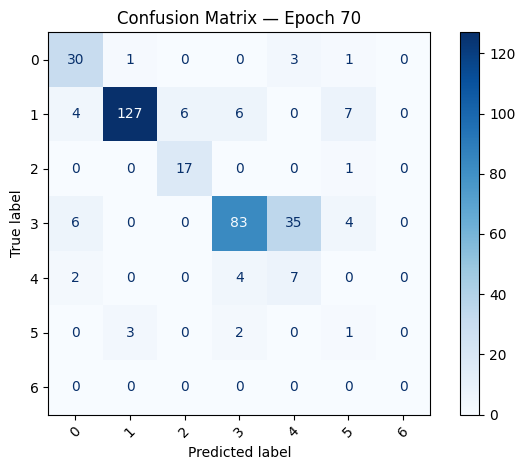

[71/100] Train Loss: 0.1858 | Train Acc: 0.9017 | Val Loss: 0.9854 | Val Acc: 0.7549 | Val Macro F1: 0.6156 | Val PR AUC: 0.6512


[72/100] Train Loss: 0.1765 | Train Acc: 0.9085 | Val Loss: 0.9914 | Val Acc: 0.7805 | Val Macro F1: 0.5378 | Val PR AUC: 0.6479


[73/100] Train Loss: 0.1850 | Train Acc: 0.9061 | Val Loss: 0.9955 | Val Acc: 0.7777 | Val Macro F1: 0.6083 | Val PR AUC: 0.6481


[74/100] Train Loss: 0.1729 | Train Acc: 0.9136 | Val Loss: 0.9752 | Val Acc: 0.7748 | Val Macro F1: 0.6130 | Val PR AUC: 0.6537


[75/100] Train Loss: 0.1708 | Train Acc: 0.9123 | Val Loss: 1.0498 | Val Acc: 0.7636 | Val Macro F1: 0.5710 | Val PR AUC: 0.6477


[76/100] Train Loss: 0.1688 | Train Acc: 0.9152 | Val Loss: 1.0366 | Val Acc: 0.7578 | Val Macro F1: 0.5052 | Val PR AUC: 0.6484


[77/100] Train Loss: 0.1603 | Train Acc: 0.9201 | Val Loss: 1.0158 | Val Acc: 0.7663 | Val Macro F1: 0.5217 | Val PR AUC: 0.6503


[78/100] Train Loss: 0.1650 | Train Acc: 0.9082 | Val Loss: 1.0566 | Val Acc: 0.7549 | Val Macro F1: 0.6018 | Val PR AUC: 0.6491


[79/100] Train Loss: 0.1500 | Train Acc: 0.9215 | Val Loss: 1.0676 | Val Acc: 0.7636 | Val Macro F1: 0.5871 | Val PR AUC: 0.6469


[80/100] Train Loss: 0.1704 | Train Acc: 0.9086 | Val Loss: 1.0871 | Val Acc: 0.7807 | Val Macro F1: 0.5987 | Val PR AUC: 0.6487


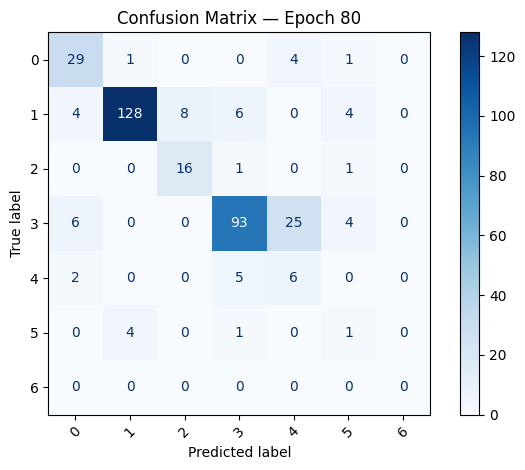

[81/100] Train Loss: 0.1523 | Train Acc: 0.9264 | Val Loss: 1.0360 | Val Acc: 0.7805 | Val Macro F1: 0.6069 | Val PR AUC: 0.6483


[82/100] Train Loss: 0.1463 | Train Acc: 0.9207 | Val Loss: 1.0881 | Val Acc: 0.7578 | Val Macro F1: 0.5189 | Val PR AUC: 0.6490


[83/100] Train Loss: 0.1545 | Train Acc: 0.9153 | Val Loss: 1.0557 | Val Acc: 0.7521 | Val Macro F1: 0.5102 | Val PR AUC: 0.6498


[84/100] Train Loss: 0.1508 | Train Acc: 0.9299 | Val Loss: 1.0443 | Val Acc: 0.7606 | Val Macro F1: 0.6037 | Val PR AUC: 0.6505


[85/100] Train Loss: 0.1407 | Train Acc: 0.9289 | Val Loss: 1.0541 | Val Acc: 0.7634 | Val Macro F1: 0.5246 | Val PR AUC: 0.6473


[86/100] Train Loss: 0.1288 | Train Acc: 0.9347 | Val Loss: 1.0649 | Val Acc: 0.7722 | Val Macro F1: 0.5210 | Val PR AUC: 0.6514


[87/100] Train Loss: 0.1431 | Train Acc: 0.9321 | Val Loss: 1.1412 | Val Acc: 0.7235 | Val Macro F1: 0.5667 | Val PR AUC: 0.6484


[88/100] Train Loss: 0.1393 | Train Acc: 0.9206 | Val Loss: 1.0933 | Val Acc: 0.7578 | Val Macro F1: 0.5144 | Val PR AUC: 0.6504


[89/100] Train Loss: 0.1377 | Train Acc: 0.9338 | Val Loss: 1.1111 | Val Acc: 0.7665 | Val Macro F1: 0.5169 | Val PR AUC: 0.6466


[90/100] Train Loss: 0.1325 | Train Acc: 0.9362 | Val Loss: 1.0809 | Val Acc: 0.7722 | Val Macro F1: 0.6170 | Val PR AUC: 0.6555


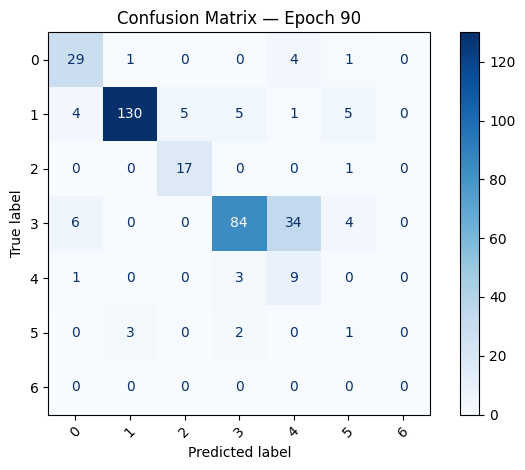

[91/100] Train Loss: 0.1285 | Train Acc: 0.9429 | Val Loss: 1.0986 | Val Acc: 0.7805 | Val Macro F1: 0.6197 | Val PR AUC: 0.6499


[92/100] Train Loss: 0.1346 | Train Acc: 0.9373 | Val Loss: 1.1226 | Val Acc: 0.7866 | Val Macro F1: 0.5128 | Val PR AUC: 0.6463


[93/100] Train Loss: 0.1283 | Train Acc: 0.9386 | Val Loss: 1.1086 | Val Acc: 0.7634 | Val Macro F1: 0.6225 | Val PR AUC: 0.6518


[94/100] Train Loss: 0.1145 | Train Acc: 0.9440 | Val Loss: 1.1348 | Val Acc: 0.7492 | Val Macro F1: 0.5118 | Val PR AUC: 0.6522


[95/100] Train Loss: 0.1174 | Train Acc: 0.9429 | Val Loss: 1.1936 | Val Acc: 0.7720 | Val Macro F1: 0.5311 | Val PR AUC: 0.6515


[96/100] Train Loss: 0.1125 | Train Acc: 0.9489 | Val Loss: 1.1855 | Val Acc: 0.7835 | Val Macro F1: 0.5272 | Val PR AUC: 0.6494


[97/100] Train Loss: 0.1215 | Train Acc: 0.9416 | Val Loss: 1.0481 | Val Acc: 0.7748 | Val Macro F1: 0.6140 | Val PR AUC: 0.6555


[98/100] Train Loss: 0.1112 | Train Acc: 0.9459 | Val Loss: 1.1285 | Val Acc: 0.7720 | Val Macro F1: 0.5228 | Val PR AUC: 0.6505


[99/100] Train Loss: 0.1144 | Train Acc: 0.9460 | Val Loss: 1.1257 | Val Acc: 0.7720 | Val Macro F1: 0.6050 | Val PR AUC: 0.6497


[100/100] Train Loss: 0.1077 | Train Acc: 0.9447 | Val Loss: 1.1389 | Val Acc: 0.7606 | Val Macro F1: 0.5358 | Val PR AUC: 0.6519


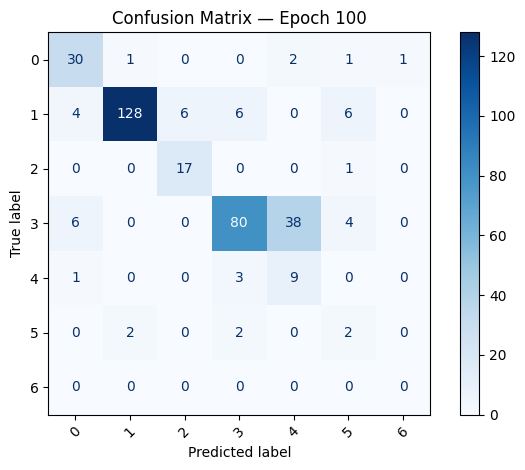

Saving final model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/final_weights_005.pt


In [10]:
# @title Обучение ДУЭТ

train_dataset = TensorDataset(
    torch.tensor(x_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
val_dataset = TensorDataset(
    torch.tensor(x_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

test_dataset = TensorDataset(
    torch.tensor(x_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)


train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size)

# --- 6. Инициализация модели ---
model = DUETModel(config).to(device)

# --- 7. Обучение модели ---
trained_model = train.train_model(
    model,
    config,
    train_loader,
    val_loader,
    device=device,
    class_weights = class_weights
)

In [ ]:
# cl_0 - падение после роста
# cl_1 - падение
# cl_2 - рост после падения
# cl_3 - рост
# cl_4 - флэт после роста
# cl_5 - флэт после падения
# cl_6 - падение после флэта

In [11]:
# Загрузка весов

model.load_state_dict(torch.load(config.checkpoint_best)) # загрузка лучших весов
# model.load_state_dict(torch.load(config.checkpoint_final)) # загрузка финальных весов
model.eval()

DUETModel(
  (revin): RevIN()
  (tcm): TCM(
    (decomp): SeriesDecomposition(
      (avg_pool): AvgPool1d(kernel_size=(25,), stride=(1,), padding=(12,))
    )
    (extractors): ModuleList(
      (0-2): 3 x LinearPatternExtractor(
        (projection): Linear(in_features=120, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (router): Sequential(
      (0): Linear(in_features=60, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=3, bias=True)
    )
  )
  (ccm): CCM(
    (embedding): Linear(in_features=56, out_features=128, bias=True)
    (metric): Linear(in_features=128, out_features=128, bias=False)
  )
  (fusion): Fusion()
  (head): DUETHead(
    (head): Sequential(
      (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (1): Linear(in_features=256, out_features=256, bias=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=256, out_featu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 7.0 MB/s eta 0:00:00
              precision    recall  f1-score   support

           0       0.64      0.88      0.74         8
           1       0.00      0.00      0.00         2
           3       0.82      0.64      0.72        14
           4       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         7

    accuracy                           0.52        31
   macro avg       0.29      0.30      0.29        31
weighted avg       0.53      0.52      0.52        31


Metrics:
ACCURACY: 0.52
MACRO_PRECISION: 0.29
MACRO_RECALL: 0.30
MACRO_F1: 0.29
PR_AUC_MACRO: nan


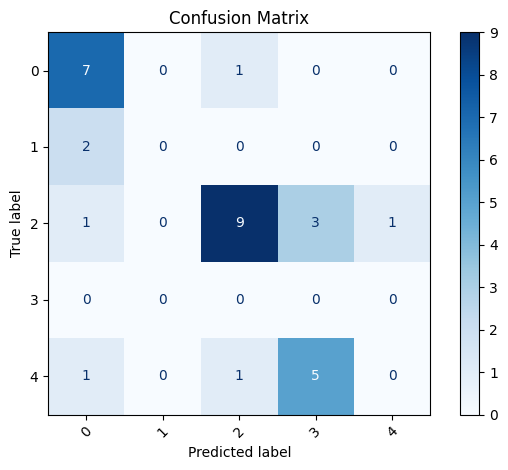

[warn] Skipping PR for class 2: no positive samples in y_true.
[warn] Skipping PR for class 4: no positive samples in y_true.
[warn] Skipping PR for class 5: no positive samples in y_true.


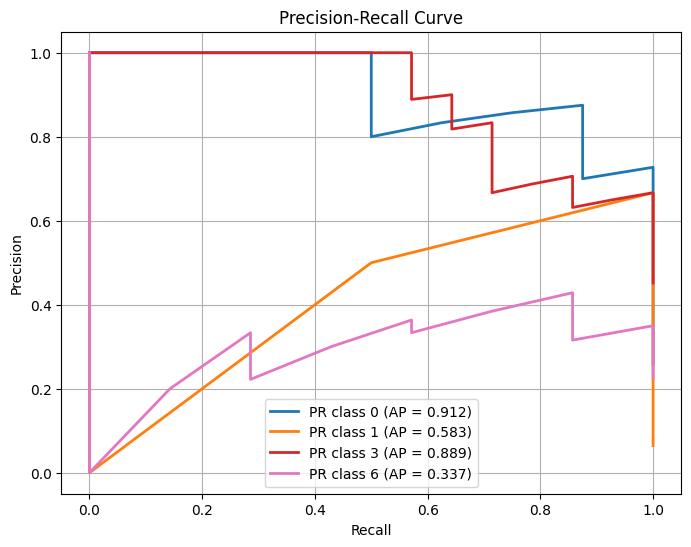

[warn] Skipping ROC for class 2: only one class present in y_true_bin.
[warn] Skipping ROC for class 4: only one class present in y_true_bin.
[warn] Skipping ROC for class 5: only one class present in y_true_bin.


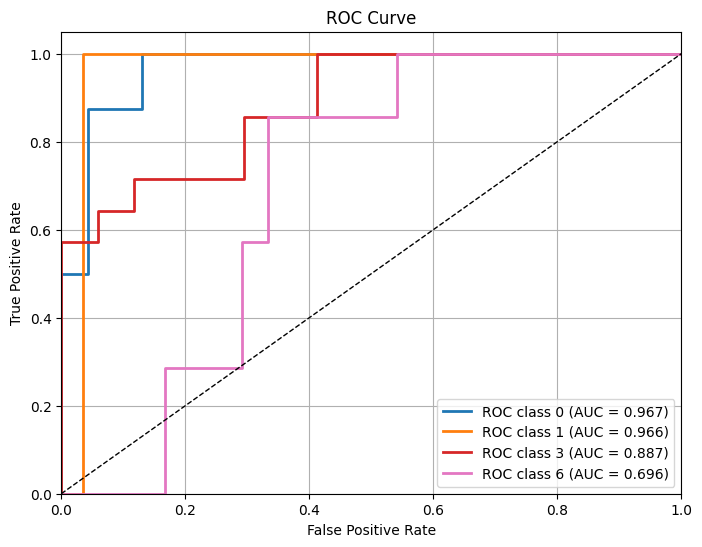


Examples of predictions:
Sample 21: True=3, Pred=3 ✅
Sample 17: True=6, Pred=4 ❌
Sample 26: True=6, Pred=4 ❌
Sample 5: True=3, Pred=0 ❌
Sample 4: True=0, Pred=0 ✅
Sample 8: True=6, Pred=3 ❌
Sample 16: True=3, Pred=4 ❌
Sample 27: True=0, Pred=0 ✅
Sample 25: True=6, Pred=4 ❌
Sample 0: True=6, Pred=4 ❌


In [12]:
# @title Оценка модели
!pip install mplfinance
from pipeline.visualiser import plot_pr_auc, plot_roc_auc

y_true, y_pred, y_prob = evaluate.evaluate_model(model, test_loader, return_proba=True, device="cuda") # test_loader

# Подсчёт метрик
metrics = evaluate.compute_metrics(y_true, y_pred)
print("\nMetrics:")
for metric, value in metrics.items():
    print(f"{metric.upper()}: {value:.2f}")


# Матрица ошибок
evaluate.plot_confusion_matrix(y_true, y_pred)
plot_pr_auc(y_true, y_prob, n_classes=config.num_classes)
plot_roc_auc(y_true, y_prob, n_classes=config.num_classes)

# Примеры предсказаний
evaluate.plot_classification_examples(y_true, y_pred, n=10)

In [29]:
# @title Предикт по валидации или тесту для быстрой проверки

from pipeline.predict import predict_dataset_batched

# pred_t0 = fold0["val"]["t0"]
# pred_x = fold0["val"]["X"]

# pred_t0 = fold0["test"]["t0"]
# pred_x = fold0["test"]["X"]

pred_t0 = fold0["train"]["t0"]
pred_x = fold0["train"]["X"]

# Предсказания
y_pred, y_probs = predict_dataset_batched(model, pred_x, config, device="cuda", threshold=None)

print(f"Prediction labels array shape {y_pred.shape}")
print(f"Prediction probs array shape {y_probs.shape}")


Prediction labels array shape (397001,)
Prediction probs array shape (397001, 7)


In [30]:
# --- Слияние предиктов с исходным датасетом по индексу ---
# t0 хранит индексные позиции исходного ряда для каждого окна.
# В итоговом DataFrame оставляем все строки, а предикты заполняем только
# в позициях t0 (для валидных окон), остальные значения = -1.

pred_index = df.index[pred_t0]
print(f"index {pred_index.shape}")
pred_series = pd.Series(-1, index=df.index, name="pred")

pred_series.loc[pred_index] = y_pred

df_with_pred = df.copy()
df_with_pred["pred"] = pred_series

df_with_pred[["target", "pred"]].head()

# Фильтруем по аномалиям, чтобы не видеть предикт по всем таймстэмпам
df_with_pred.loc[df_with_pred['zScore_bin']==0, 'pred'] = -1
print(df_with_pred['pred'].value_counts())

anomaly_indx = df_with_pred.loc[df_with_pred['pred'] != -1].index
sample_labels = df_with_pred.loc[anomaly_indx, 'pred'].to_numpy()

index (397001,)
pred
-1    566595
 1       225
 3       163
 4       137
 0        62
 5        54
 2        40
 6        25
Name: count, dtype: int64


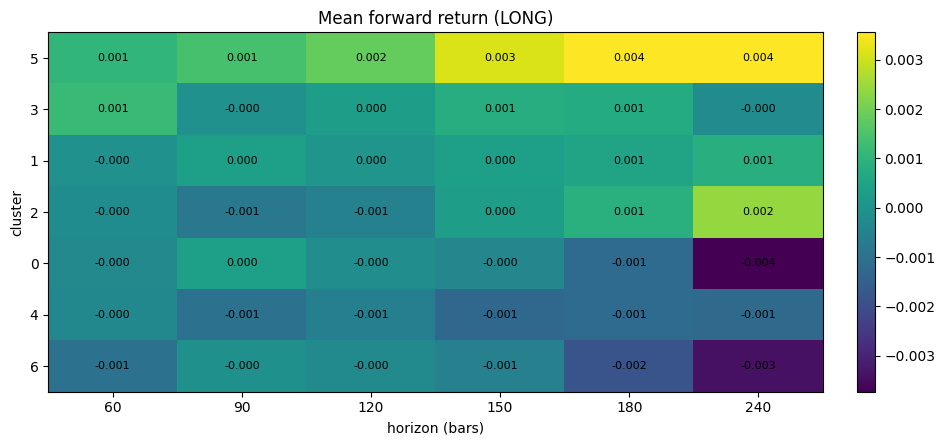

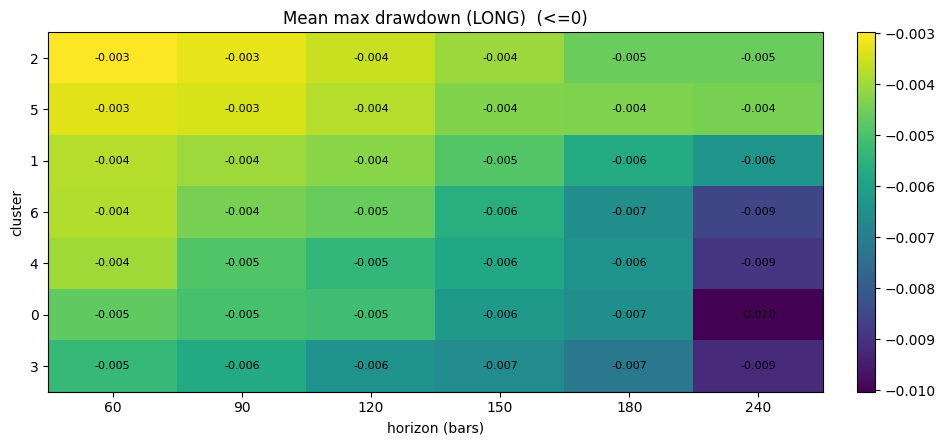

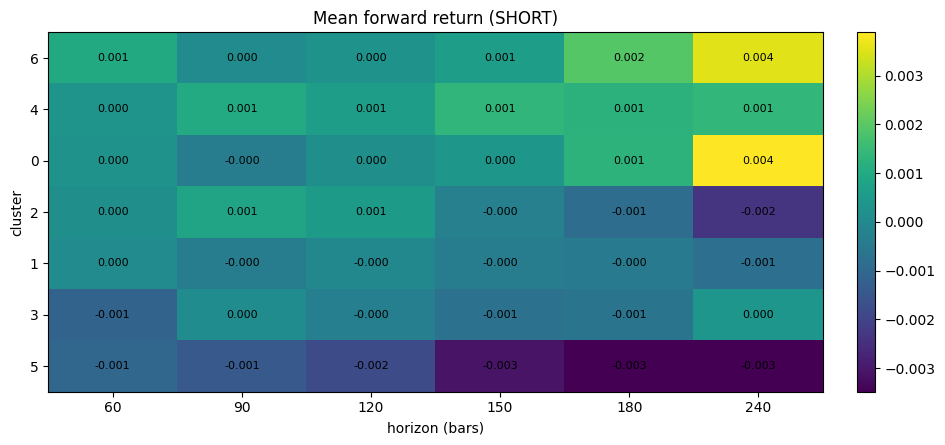

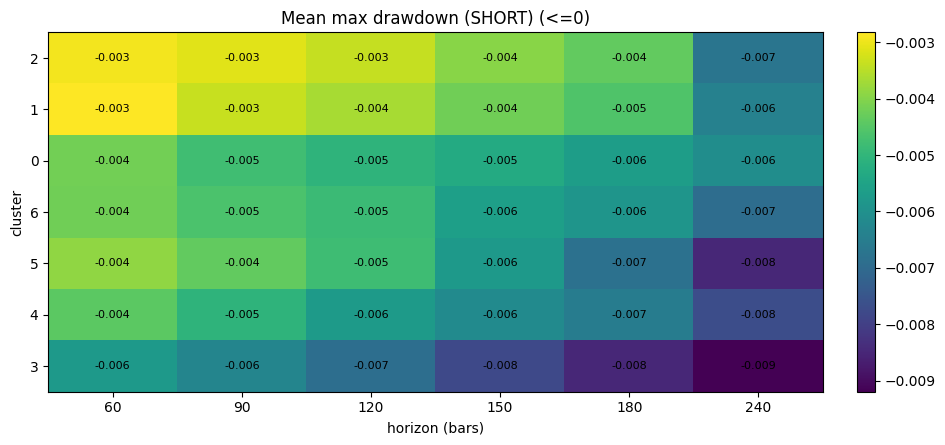

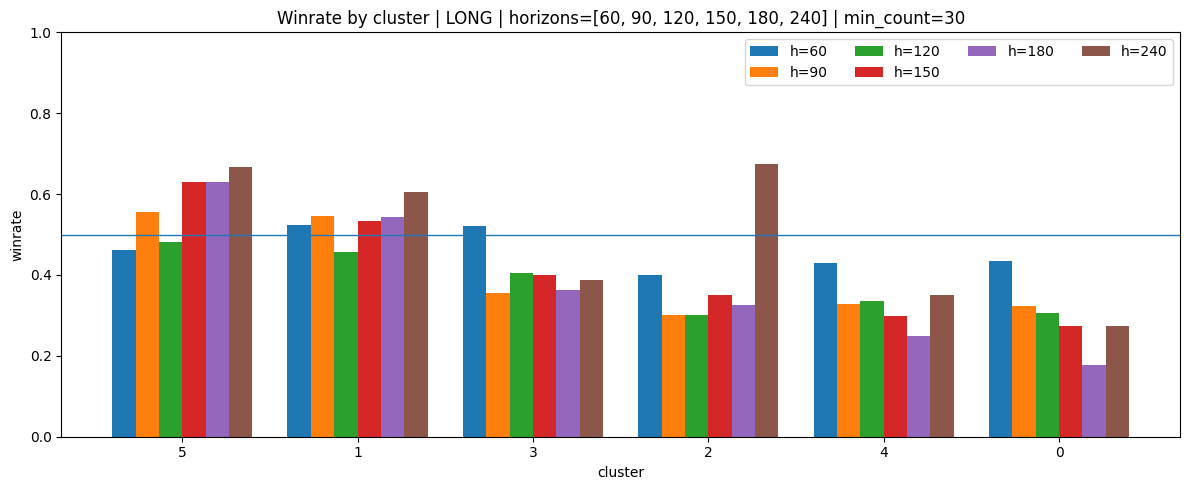

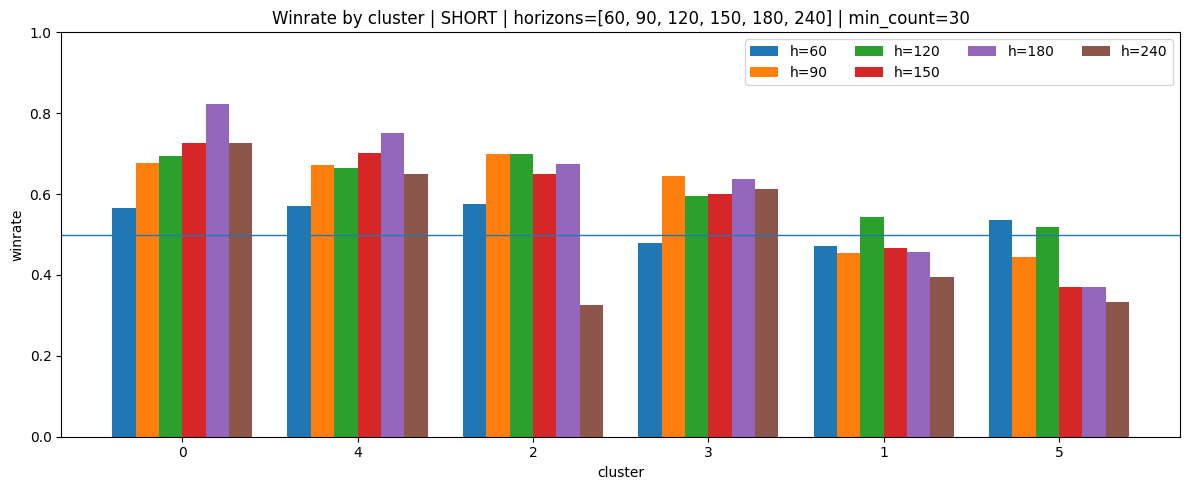

In [31]:
# df_prices: DataFrame с колонкой Close и тем же индексом, что и anomaly_indexes
# anomaly_indexes: индексы аномалий (int позиции или timestamps)
# sample_labels: кластер для каждой аномалии

from drive.MyDrive.stocks.duet.duet_class.pipeline.analyze_future_effect import (
    ClusterFutureEffect,
    FutureEffectConfig,
    ClusterFutureEffectViz,
)

HORIZONS = (60, 90, 120, 150, 180, 240)

e = ClusterFutureEffect(FutureEffectConfig(horizons=HORIZONS, price_col="Close"))
# ЕСЛИ ДАВАЛИ БУДУЩЕЕ, ТО ОБЯЗАТЕЛЬНО СМЕЩАЕМ ТОЧКУ ВХОДА-------------\/
out = e.evaluate(df_with_pred, anomaly_indx, sample_labels, open_price_shift=20)

per_event = out["per_event"]   # детально по каждой аномалии и горизонту
summary = out["summary"]       # агрегаты по кластеру и горизонту
# print(summary.sort_values(["h", "ret_long_mean"], ascending=[True, False]).head(20))

viz = ClusterFutureEffectViz()
viz.plot_heatmaps(summary)

viz.plot_winrate_bars(
    summary,
    horizons=HORIZONS,
    side="long",
    min_count=30,
    top_k=20,
    sort_by="mean",
)
viz.plot_winrate_bars(
    summary,
    horizons=HORIZONS,
    side="short",
    min_count=30,
    top_k=20,
    sort_by="mean",
)

In [ ]:
from pipeline.visualiser import plot_candles_with_add_around_index

# ЕСЛИ ДАВАЛИ БУДУЩЕЕ, ТО РЕАЛЬНАЯ ТОЧКа ВХОДА СМЕЩЕНА ВПРАВО

LABEL_TO_SHOW = 0

add = {
    # 0: ['BBL_20_2.0', 'BBU_20_2.0', 'BBM_20_2.0'],
    1: ['rsi_60'],
    # 2: ['zScore_mean', 'zScore_median'],
}


for i, l in zip(anomaly_indx, sample_labels):
    if l == LABEL_TO_SHOW:
        plot_candles_with_add_around_index(
            df,
            style='charles',
            figsize=(16,8),
            center_idx=i,
            window=120,
            add=add,
            volume=False,
        )

Output hidden; open in https://colab.research.google.com to view.